In [1]:
import glob
import os
import numpy as np
import soundfile as sf
import librosa
import torch
import torch.nn.functional as F
from gammatone.filters import make_erb_filters, erb_space, erb_filterbank
from scipy.signal import fftconvolve
from tqdm import tqdm
import matplotlib.pyplot as plt
import math
import gc

from wiring_efficiency_utils import *

In [2]:
def nn_train(x_batch, y_batch, network, time_window=100, iters=1000, loss_beta=1e-2):

    avg_loss = 0

    x_batch = x_batch / (x_batch.max() + 1e-11)
    y_batch = y_batch / (y_batch.max() + 1e-11)

    progress_bar = tqdm(range(iters))
    for i in progress_bar:

        b_idx = torch.randint(x_batch.shape[0], (1,))
        t_idx = torch.randint(x_batch.shape[-1] - time_window, (1,))

        x = x_batch[b_idx, :, t_idx:t_idx+time_window][None]

        if x.mean() > 0.01:

            y = y_batch[b_idx, :, t_idx:t_idx+time_window][None]

            plt.imshow(x[0,0].cpu())
            plt.show()
            plt.imshow(y[0,0].cpu())
            plt.show()

            y_reco = network['activ'](network['model'](x))
                
            y_reco = y_reco.view(x.shape)
        
            loss, loss_std = nn_loss(network, y, y_reco)
        
            network['optim'].zero_grad()
            loss.backward()
            network['optim'].step()

            sim = cosim(y.detach().cpu(), y_reco.detach().cpu(), True)
            avg_loss = (1-loss_beta)*avg_loss + loss_beta*loss

        progress_bar.set_description('similarity:{:.3f}'.format( 
            avg_loss
        ))

        torch.cuda.empty_cache()

In [3]:
pool_K = 32

In [23]:
def load_audio(path, target_sr=16_000):
    """Load a file, convert to mono, resample if needed, return float32."""
    x, sr = sf.read(path)
    if x.ndim > 1:                  # stereo → mono
        x = x.mean(axis=1)
    if sr != target_sr:             # resample
        x = librosa.resample(x, orig_sr=sr, target_sr=target_sr)
    return x.astype(np.float32)

def process_folder(
        audio_dir: str = "./audio",
        sr:        int  = 16_000,
        n_filters: int  = 90,
        low_freq:  float = 50.0,
        batch_size: int  = 16,          # you can raise this now
        chunk_len:  int  = 80_000,      # samples per chunk (~3.75 s at 16 kHz)
        device:     str  = "cuda",
        lp_fc:      int  = 770         # IHC low-pass (Hz)
):
    """
    Returns a tensor [N_files, n_filters, n_frames] of mean firing-rates.
    Gain-control is *not* applied so you can do it later.
    """
    # ---------- pre-compute constants ----------
    dt      = 1.0 / sr
    alpha_lp   = math.exp(-lp_fc * dt)

    # ---------- build filterbank ----------
    center_freqs = erb_space(low_freq=low_freq, high_freq=sr/2, num=n_filters)
    irs = erb_filterbank(
            np.pad([1.0], (0,512)),                       # impulse
            make_erb_filters(sr, center_freqs)
          )                                               # [F,L]
    irs = torch.from_numpy(irs).unsqueeze(1).float().to(device)   # [F,1,L]

    # ---------- gather .wav paths ----------
    wav_paths = sorted(glob.glob(os.path.join(audio_dir, "*.wav")))
    if not wav_paths:
        raise FileNotFoundError(f"No .wav files in {audio_dir}")

    # ---------- process in file-batches ----------
    rates = torch.empty((len(wav_paths), n_filters, chunk_len // pool_K))
    progress_bar = tqdm(range(0, len(wav_paths), batch_size))
    for i in progress_bar:
        batch_paths = wav_paths[i : i+batch_size]

        # ---- load & pad to longest in this mini-batch ----
        waves, max_len = [], 0
        for p in batch_paths:
            sig = load_audio(p, sr)
            waves.append(torch.from_numpy(sig))

        x_batch = torch.stack(waves).unsqueeze(1).to(device)      # [B,1,T]#

        # ➊ filterbank
        y = F.conv1d(x_batch, irs, padding=irs.shape[-1]//2)  # [B,F,Tc]
        
        # ➋ half-wave rectification
        y.clamp_(min=0.0)

        # ➌ 1-pole low-pass (in-place)
        for n in range(1, y.shape[-1]):
            y[..., n] = (1-alpha_lp)*y[..., n] + alpha_lp*y[..., n-1]

        # ➌ 1-pole low-pass (in-place)
        for n in range(1, y.shape[-1]):
            y[..., n] = (1-alpha_lp)*y[..., n] + alpha_lp*y[..., n-1]

        y = y[..., ::pool_K]  # or whatever your stride is 

        gc_rates = y
        gc_rates = freq_suppression(gc_rates, sigma_f=2, sigma_t=0.001, k_f=2, k_t=2)
        gc_rates = power_law_adapt(gc_rates, alpha=0.6, p=1)
        gc_rates = apply_gain_control(gc_rates, sigma_f=6, sigma_t=0.02, eps=2e-5, scaler=0.3)

        # ---- concat chunks in time, move to CPU to free GPU mem ----
        rates[i:i+batch_size] = gc_rates.cpu()

        # optional: clear GPU cache
        torch.cuda.empty_cache()

    gc.collect()

    print('processed, saving.')

    torch.save(rates,'./x_processed.pt')      # ready for later gain-control

In [13]:
def freq_suppression(x, sigma_f, sigma_t, k_f, k_t):

    fsize = int(k_f * sigma_f) * 4 + 1
    fps = 16000 / pool_K
    tsize = int(k_t * sigma_t * fps) * 2 + 1
    
    f_rng = torch.arange(fsize) - fsize//2
    t_rng = torch.arange(tsize).flip(0)

    dist = (f_rng[:, None].abs() / sigma_f + t_rng[None] / (sigma_t * fps)).abs()
    kernel_pos = torch.exp(-dist)
    kernel_pos /= kernel_pos.sum()

    dist = (f_rng[:, None].abs() / sigma_f / k_f + t_rng[None] / (sigma_t * fps) / k_t).abs()
    kernel_neg =  torch.exp(-dist)
    kernel_neg /= kernel_neg.sum()
    
    kernel = kernel_pos - kernel_neg
    kernel = kernel[None,None].to(x.device)

    #plt.imshow(kernel_neg.cpu())
    #plt.show()
    #plt.imshow(kernel_pos.cpu())
    #plt.show()
    
    
    b,f,t = x.shape
    x_pad = F.pad(x[:, None], (kernel.shape[-1]-1, 0, kernel.shape[-2]//2, kernel.shape[-2]//2))
    y = F.conv2d(x_pad, kernel)
    y = torch.relu(y)[:,0]

    return y

In [14]:
def power_law_adapt(x, alpha, p, frame_dur=1/16000*pool_K):

    b, f, t = x.shape
    device = x.device
    
    # Create a 1D power-law kernel: k[tau] = 1 / (tau+1)^p
    tau = torch.arange(t, dtype=torch.float32, device=device) * frame_dur
    kernel = 1.0 / (tau + 1)**p

    #plt.plot(kernel.cpu())
    #plt.show()

    #plt.ylim(0,1)
    #plt.plot(kernel.cpu().flip(0))
    #plt.show()
    
    kernel = kernel / kernel.sum()  # normalize to avoid scaling drift
    kernel = kernel.view(1, 1, -1).flip(2)  # shape [1,1,T] for conv

    # Convolve along time using group convolution (per frequency channel)
    x_flat = x.view(b * f, 1, t)
    avg_activity = F.conv1d(x_flat, kernel, padding=t - 1)
    avg_activity = avg_activity[:, :, :t]  # trim to match length
    avg_activity = avg_activity.view(b, f, t)

    #plt.imshow(avg_activity.cpu()[3,:,[:s, -s:]])
    #plt.show()

    # Subtractive adaptation (classic power-law)
    return torch.relu(x - alpha * avg_activity)


In [15]:
def apply_gain_control(x, sigma_f, sigma_t, eps, scaler):
    
    fsize = int(sigma_f) * 4 + 1
    fps = 16000 / pool_K
    tsize = int(sigma_t * fps) * 2 + 1
    
    f_rng = torch.arange(fsize) - fsize//2
    t_rng = torch.arange(tsize).flip(0)

    dist = (f_rng[:, None].abs() / sigma_f + t_rng[None] / (sigma_t * fps)).abs()
    kernel = torch.exp(-dist)
    kernel /= kernel.sum()
    
    kernel = kernel[None,None].to(x.device)

    #plt.imshow(kernel.cpu()[0,0])
    #plt.show()    
    
    b,f,t = x.shape
    x_pad = F.pad(x[:, None], (kernel.shape[-1]-1, 0, kernel.shape[-2]//2, kernel.shape[-2]//2))
    y = F.conv2d(x_pad, kernel)[:,0]
    y = x / (y + eps)

    y = torch.tanh(y * scaler)

    return y

In [24]:
process_folder()

100%|█████████████████████████████████████████| 125/125 [14:40<00:00,  7.04s/it]


processed, saving.


In [17]:
rates = torch.load('./x_processed.pt').cuda()[:,:,:2000]
rates = rates[rates.sum([1,2])>1e-3]

gc_rates = rates
#gc_rates = freq_suppression(gc_rates, sigma_f=2, sigma_t=0.001, k_f=2, k_t=2)
#gc_rates = power_law_adapt(gc_rates, alpha=0.7, p=1)
#gc_rates = apply_gain_control(gc_rates, sigma_f=6, sigma_t=0.02, eps=2e-5, scaler=0.3)

similarity = cosim(rates[:,None], gc_rates[:,None])
hoyer1 = (np.sqrt(rates.shape[-1]*rates.shape[-2]) - gc_rates.sum([1,2]) / (torch.sqrt((gc_rates**2).sum([1,2])) + 1e-11)) / (np.sqrt(rates.shape[-1]*rates.shape[-2]) - 1)

def norm_entropy(x):

    # x: [b, f, t] (nonnegative values, e.g. firing rates)
    p = x[x>0]
    p = p / (p.sum() + 1e-12)  # normalize to probability per sample
    entropy = -(p * (p + 1e-12).log()).sum() / torch.log(torch.tensor(x.shape[1]*x.shape[2]*x.shape[0], dtype=x.dtype))
    return entropy  # scalar in [0,1], averaged over batch

u = norm_entropy(gc_rates)

print(similarity, hoyer1.mean(), similarity * hoyer1.mean(), u)

tensor(1.) tensor(0.6271, device='cuda:0') tensor(0.6271, device='cuda:0') tensor(0.8866, device='cuda:0')


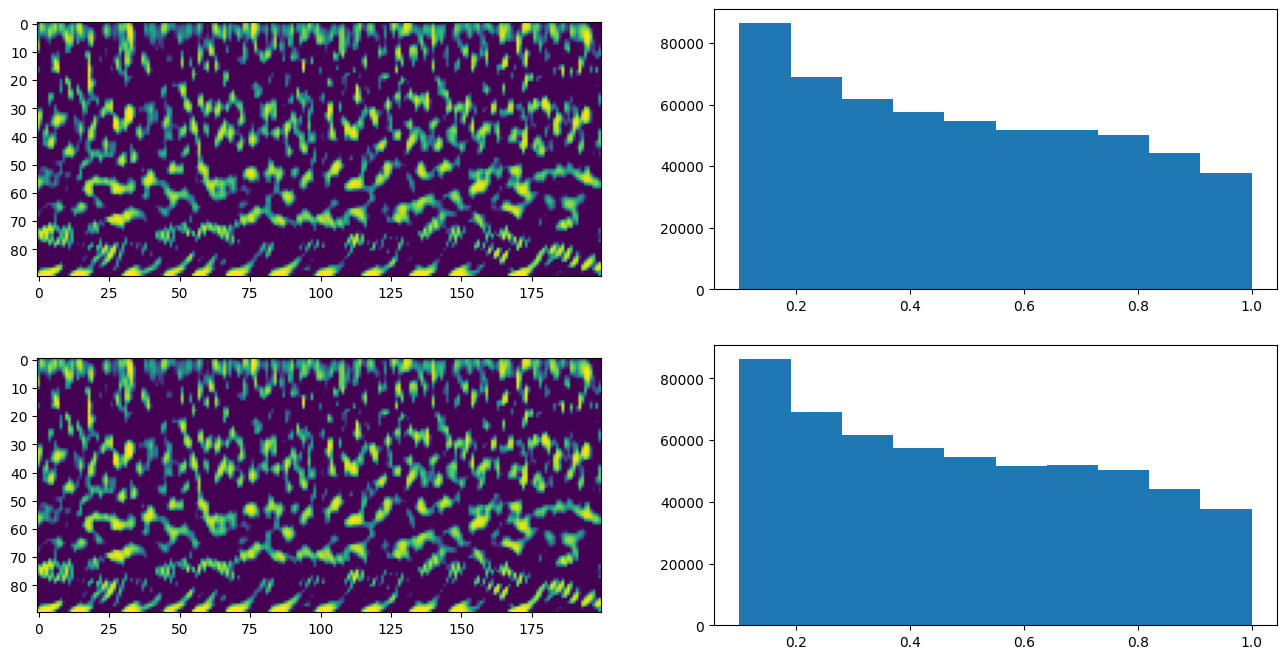

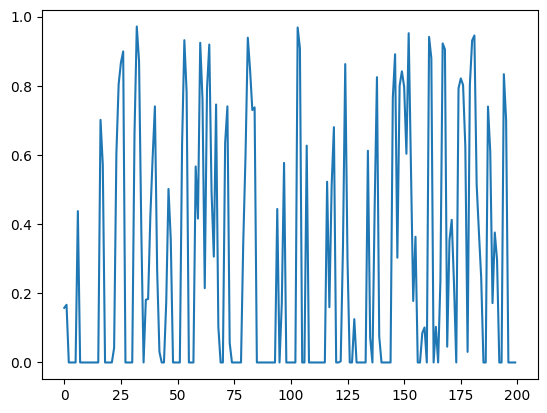

In [22]:
start = 500
s = 200
i = 15

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
plt.imshow(rates[i].cpu()[:, start:start+s])
plt.subplot(2,2,2)
plt.hist(rates[rates>rates.mean()].cpu().numpy().flatten())

plt.subplot(2,2,3)
plt.imshow(gc_rates[i].cpu()[:, start:start+s])
plt.subplot(2,2,4)
plt.hist(gc_rates[gc_rates>0.1].cpu().numpy().flatten())

plt.show()

plt.plot(gc_rates[i, 30, start:start+s].cpu())
plt.show()

In [20]:
gc_rates.shape

torch.Size([15, 90, 2000])